In [1]:
!pip install kagglehub
!pip install pandas numpy matplotlib seaborn scikit-learn wordcloud nltk

In [2]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_e35b190c5da3ad061970f361d3423f3e"

In [3]:
import kagglehub

path = kagglehub.dataset_download(
    "snap/amazon-fine-food-reviews"
)

print(path)

Using Colab cache for faster access to the 'amazon-fine-food-reviews' dataset.
/kaggle/input/amazon-fine-food-reviews


In [4]:
#Load Dataset
import pandas as pd
import os

files = os.listdir(path)

print(files)

['hashes.txt', 'Reviews.csv', 'database.sqlite']


Loading a CSV

In [5]:
df = pd.read_csv(
    os.path.join(path, "Reviews.csv")
)

df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [9]:
#DATA UNDERESTANDING
df.shape


(568454, 10)

In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [11]:
df.describe()


,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,5.684540e+05
mean,284227.500000,1.743817,2.22881,4.183199,1.296257e+09
std,164098.679298,7.636513,8.28974,1.310436,4.804331e+07
min,1.000000,0.000000,0.00000,1.000000,9.393408e+08
25%,142114.250000,0.000000,0.00000,4.000000,1.271290e+09
50%,284227.500000,0.000000,1.00000,5.000000,1.311120e+09
75%,426340.750000,2.000000,2.00000,5.000000,1.332720e+09
max,568454.000000,866.000000,923.00000,5.000000,1.351210e+09


In [12]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

In [13]:
#Dataset Profiling
df.nunique()


,0
Id,568454
ProductId,74258
UserId,256059
ProfileName,218415
HelpfulnessNumerator,231
HelpfulnessDenominator,234
Score,5
Time,3168
Summary,295742
Text,393579


In [14]:
df.isnull().sum()


,0
Id,0
ProductId,0
UserId,0
ProfileName,26
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,27
Text,0


In [15]:
df.describe(include='object')

,ProductId,UserId,ProfileName,Summary,Text
count,568454,568454,568428,568427,568454
unique,74258,256059,218415,295742,393579
top,B007JFMH8M,A3OXHLG6DIBRW8,"C. F. Hill ""CFH""",Delicious!,"This review will make me sound really stupid, ..."
freq,913,448,451,2462,199


In [16]:
#Check missing values

df.isnull().sum()

#Fill text columns

df["Summary"] = df["Summary"].fillna("Unknown")
df["Text"] = df["Text"].fillna("No Review")

#Verify

df.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,26
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,0
Text,0


In [17]:
#DUPLICATE ANALYSIS
df.duplicated().sum()

np.int64(0)

In [18]:
#Remove duplicates

df = df.drop_duplicates()

In [19]:
#Check

df.shape

(568454, 10)

Outlier Analysis

In [20]:

#Review Length
df["Review_Length"] = df["Text"].apply(len)

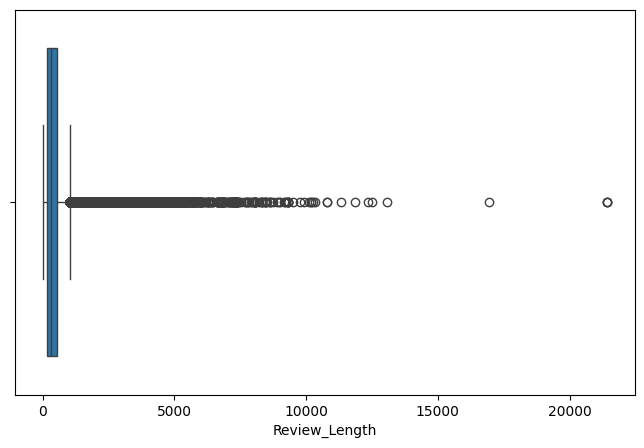

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x=df["Review_Length"])
plt.show()

In [23]:
#IQR Method
Q1 = df["Review_Length"].quantile(0.25)
Q3 = df["Review_Length"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = df[
    (df["Review_Length"] < lower) |
    (df["Review_Length"] > upper)
]

print(outliers.shape)

(38864, 11)


FEATUREE ENGINEERING

In [25]:
#Sentiment Creation

#Convert ratings into sentiment
def sentiment(score):

    if score >= 4:
        return 1

    elif score <= 2:
        return 0

    else:
        return None

In [26]:
df["Sentiment"] = df["Score"].apply(sentiment)
df = df.dropna(subset=["Sentiment"])
df["Sentiment"] = df["Sentiment"].astype(int)

In [27]:
#REVIEW LENGTH
df["Helpful_Ratio"] = (
    df["HelpfulnessNumerator"] /
    (df["HelpfulnessDenominator"] + 1)
)
df["Review_Length"] = df["Text"].apply(len)

VISUALIZATION

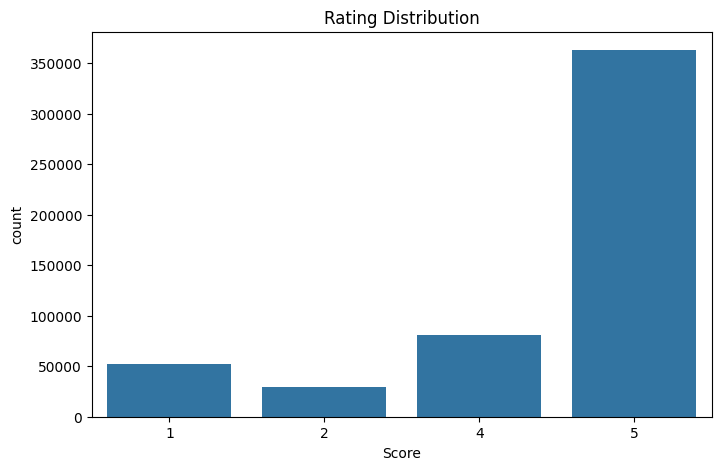

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Score",
    data=df
)

plt.title("Rating Distribution")
plt.show()

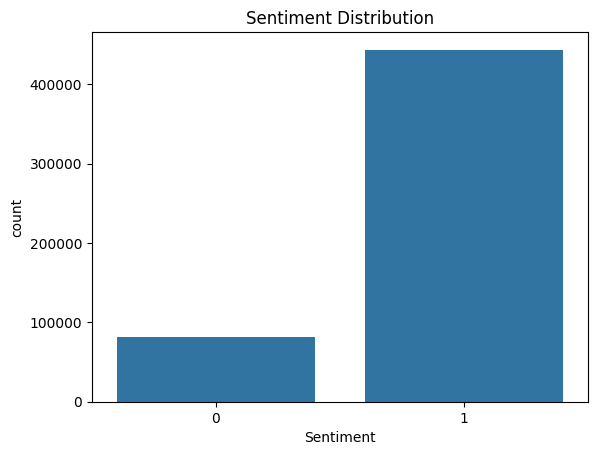

In [29]:
#Sentiment Distribution
sns.countplot(
    x="Sentiment",
    data=df
)

plt.title("Sentiment Distribution")
plt.show()

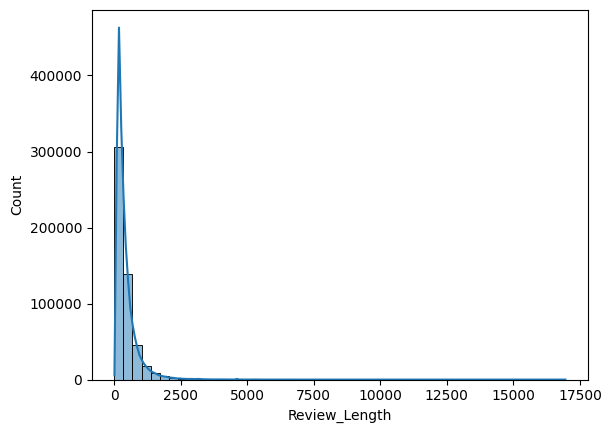

In [30]:
#Review Length Distribution
sns.histplot(
    df["Review_Length"],
    bins=50,
    kde=True
)

plt.show()

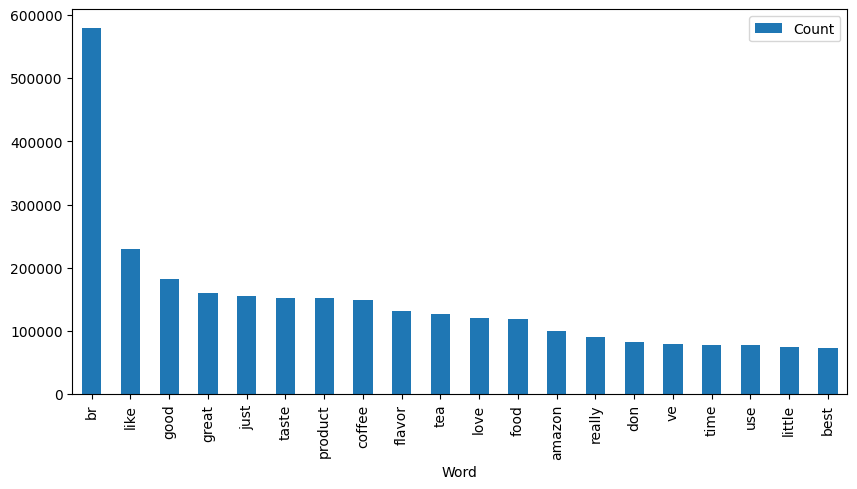

In [31]:
#Top 20 Frequent Words
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(
    stop_words='english',
    max_features=20
)

X_words = cv.fit_transform(df["Text"])

freq = X_words.toarray().sum(axis=0)

word_df = pd.DataFrame({
    "Word":cv.get_feature_names_out(),
    "Count":freq
})

word_df = word_df.sort_values(
    by="Count",
    ascending=False
)

word_df.plot(
    x="Word",
    y="Count",
    kind="bar",
    figsize=(10,5)
)

plt.show()

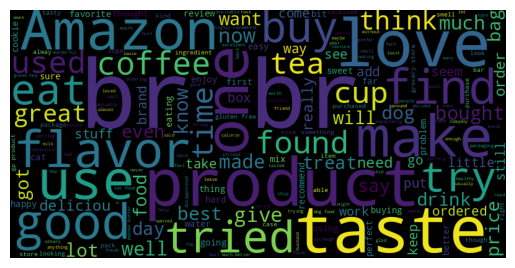

In [32]:
#wordcloud
from wordcloud import WordCloud

text = " ".join(df["Text"].astype(str))

wc = WordCloud(
    width=800,
    height=400
).generate(text)

plt.imshow(wc)
plt.axis("off")
plt.show()

In [34]:
numeric_df = df.select_dtypes(
    include=['int64','float64']
)

Correlation analysis

In [35]:
corr = numeric_df.corr()

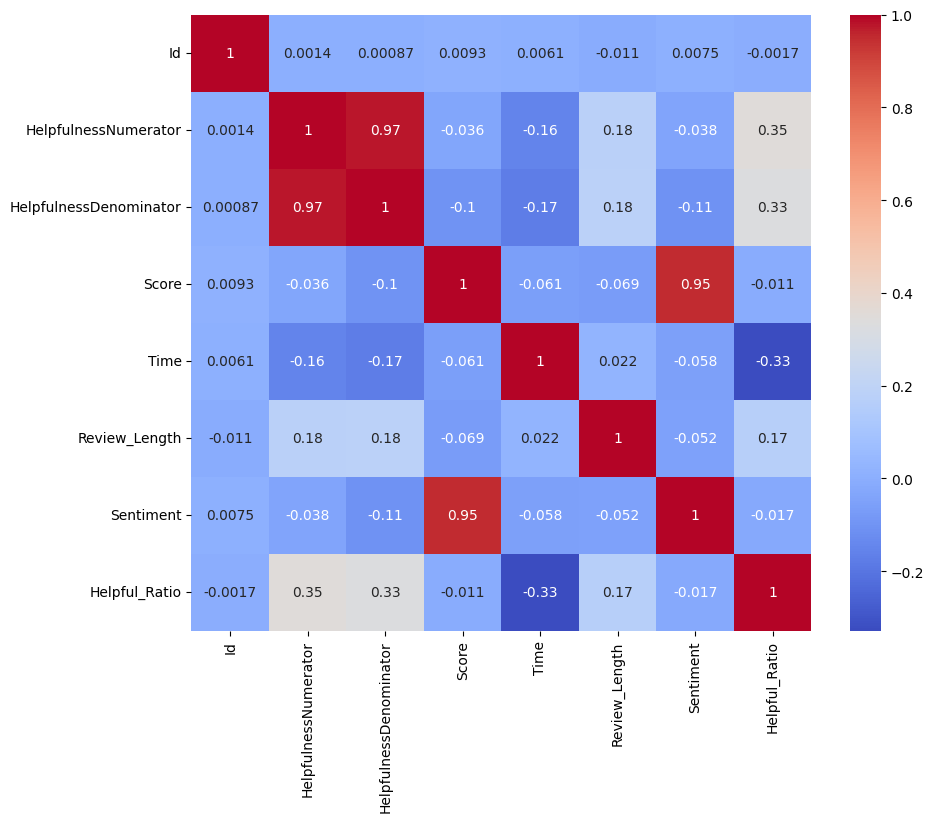

In [36]:
#Heatmap

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

MODEL DEVELOPMENT

In [33]:
#Splitting
X = df["Text"]

y = df["Sentiment"]

In [37]:
#Train Test Split

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [38]:
#Feature Selection (TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=10000
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [39]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression(max_iter=1000)

In [41]:
#Prediction
y_pred = model.predict(
    X_test_tfidf
)

In [42]:
#Performance Evaluation
#Accuracy
from sklearn.metrics import accuracy_score

accuracy_score(
    y_test,
    y_pred
)

0.9321624525736238

In [43]:
#Classification Report
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.85      0.69      0.76     16407
           1       0.94      0.98      0.96     88756

    accuracy                           0.93    105163
   macro avg       0.90      0.83      0.86    105163
weighted avg       0.93      0.93      0.93    105163



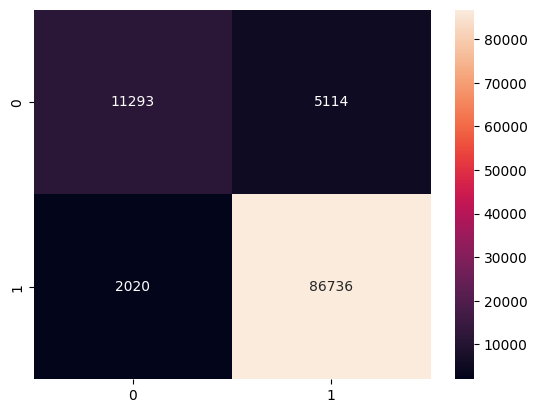

In [44]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.show()

Hyperparamater tuning

In [45]:
from sklearn.model_selection import GridSearchCV

In [46]:
param_grid = {
    'C':[0.01,0.1,1,10]
}

In [47]:
grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid.fit(
    X_train_tfidf,
    y_train
)

GridSearchCV(cv=3, estimator=LogisticRegression(max_iter=1000),
             param_grid={'C': [0.01, 0.1, 1, 10]}, scoring='accuracy')

In [48]:
#Best parameter

print(grid.best_params_)

{'C': 10}


In [49]:
#Best score

print(grid.best_score_)

0.9334341294802578


Important Words Influencing Prediction

In [50]:
feature_names = tfidf.get_feature_names_out()

coef = model.coef_[0]

In [51]:
#Positive words

top_positive = pd.DataFrame({
    "Word":feature_names,
    "Weight":coef
}).sort_values(
    by="Weight",
    ascending=False
).head(20)

top_positive

,Word,Weight
3999,great,12.664501
2480,delicious,11.905873
905,best,11.564439
6459,perfect,10.314738
5272,loves,9.226835
3202,excellent,8.934322
4284,highly,8.483892
705,awesome,8.109373
455,amazing,7.987729
5267,love,7.891885


In [52]:
#Negative words

top_negative = pd.DataFrame({
    "Word":feature_names,
    "Weight":coef
}).sort_values(
    by="Weight"
).head(20)

top_negative

,Word,Weight
9890,worst,-11.765869
2673,disappointing,-9.884284
2674,disappointment,-8.707143
8978,terrible,-8.706483
706,awful,-7.992059
2672,disappointed,-7.968119
4356,horrible,-7.645842
9400,unfortunately,-7.146492
9715,weak,-6.678738
2709,disgusting,-6.489815


BUSINESS INTERPRETATION REPORT
1. What business problem was solved?

The retailer needed an automated system to analyze thousands of customer reviews and identify customer satisfaction levels, recurring complaints, and factors affecting product reputation. The developed sentiment analysis model classifies reviews as positive or negative and provides actionable insights.

2. Which variables influenced the outcome most?

Key variables:

Review Text (strongest predictor)
Review Length
Helpful Ratio
Score (used to create sentiment label)

Most influential words are obtained from Logistic Regression coefficients.

Positive examples:
excellent,great,delicious,perfect,love

Negative examples:disappointed,terrible,waste,bad,awful


3. What insights were discovered?
Positive Findings
Majority of reviews are positive.
Customers frequently mention product quality and value.
Longer reviews often provide detailed satisfaction feedback.
Negative Findings
Complaints revolve around:
Product quality issues
Packaging damage
Delivery delays
Incorrect product expectations
Customer Behavior
Helpful reviews tend to be detailed.
Negative reviews spread faster and receive more attention.

**Final Recommendation to Management**

*Immediate Actions*:

Deploy sentiment monitoring dashboard.
Track negative reviews in real time.
Escalate products with increasing negative sentiment.
Improve packaging and logistics processes.
Prioritize complaints receiving high helpfulness votes.


*Strategic Actions*

Integrate sentiment prediction into CRM.
Generate weekly complaint trend reports.
Use NLP insights during product quality audits.
Retrain model monthly using latest reviews.
Create automated alerts when negative sentiment exceeds predefined thresholds.